In [3]:
%matplotlib notebook

<IPython.core.display.Javascript object>


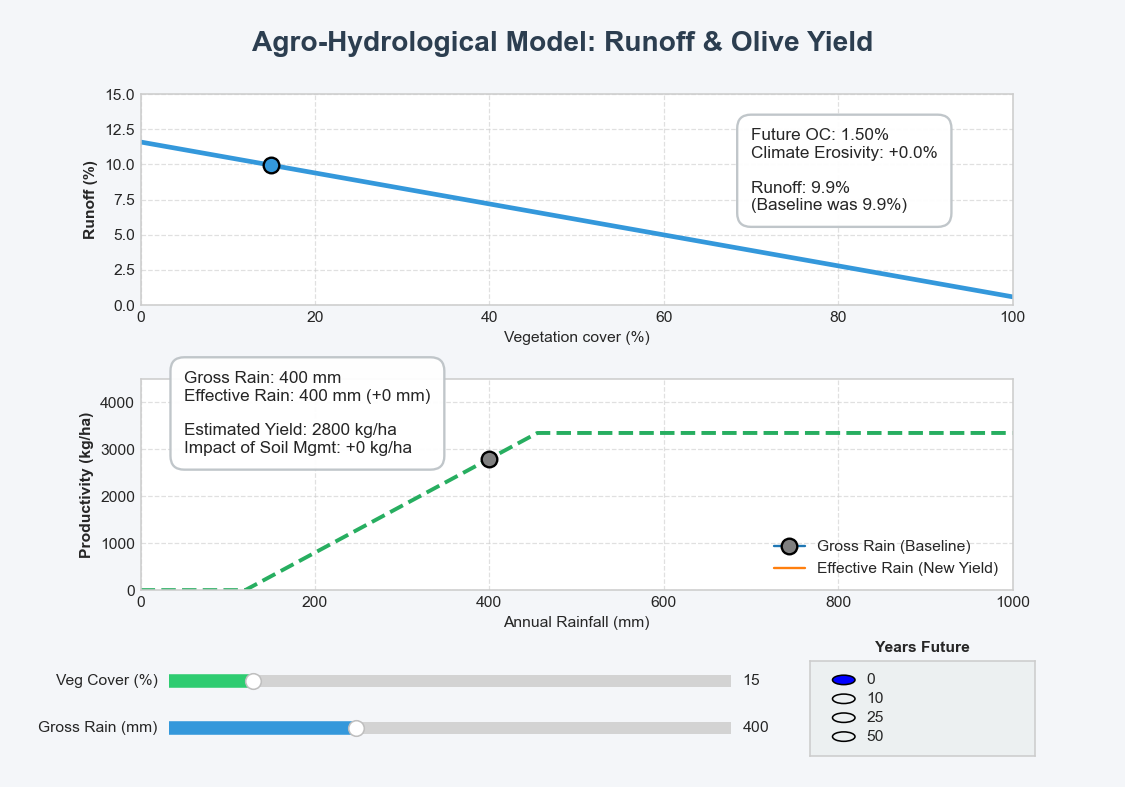

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons

# --- Handle Style Versioning ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass

# --- 1. Mathematical Models ---

def get_equilibrium_veg():
    return - (1.0 / 0.06) * np.log(1.4 / 11.47) # ~35.06%

def project_parameters(veg_cover, years):
    rain_increase_pct = years * 0.5
    baseline_oc = 1.5
    veg_eq = get_equilibrium_veg()
    annual_oc_change = (veg_cover - veg_eq) * 0.001
    future_oc = max(0.5, min(5.0, baseline_oc + (annual_oc_change * years))) 
    return rain_increase_pct, future_oc

def predict_runoff(veg_cover, rain_increase_pct, oc_pct):
    base_runoff = np.maximum(0, -0.11 * veg_cover + 11.59)
    m_rain = 1.0 + (rain_increase_pct / 100.0) * 0.5 
    m_oc = np.exp(-0.2 * (oc_pct - 1.5)) 
    return np.minimum(100.0, base_runoff * m_rain * m_oc)

def estimate_productivity(rainfall):
    return np.maximum(0, np.minimum(3350, 10 * (rainfall - 120)))

# Calculate Baseline Runoff (Assuming 15% Veg Cover, Year 0)
RO_BASELINE = predict_runoff(15.0, 0.0, 1.5) 

# --- 2. Setup the Figure and Subplots ---
fig = plt.figure(figsize=(10, 7), facecolor='#f4f6f9')
fig.suptitle('Agro-Hydrological Model: Runoff & Olive Yield', fontsize=18, fontweight='bold', color='#2c3e50', y=0.96)

# Create 2 subplots
ax1 = fig.add_subplot(211, facecolor='white')
ax2 = fig.add_subplot(212, facecolor='white')
plt.subplots_adjust(bottom=0.25, hspace=0.35) 

x_vals_veg = np.linspace(0, 100, 500)
x_vals_rain = np.linspace(0, 1000, 500)

box_style = dict(boxstyle='round,pad=0.8', facecolor='#ffffff', alpha=0.95, edgecolor='#bdc3c7', linewidth=1.5)
marker_style = dict(marker='o', markersize=10, markeredgecolor='black', markeredgewidth=1.5, zorder=10)

# Panel 1: Runoff
line_runoff, = ax1.plot(x_vals_veg, predict_runoff(x_vals_veg, 0, 1.5), '#3498db', lw=3)
dot1, = ax1.plot([], [], markerfacecolor='#3498db', **marker_style)
text1 = ax1.text(0.70, 0.45, '', transform=ax1.transAxes, fontsize=11, bbox=box_style)
ax1.set_xlim(0, 100); ax1.set_ylim(0, 15)
ax1.set_ylabel('Runoff (%)', fontweight='bold')
ax1.set_xlabel('Vegetation cover (%)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# Panel 2: Olive Productivity
ax2.plot(x_vals_rain, estimate_productivity(x_vals_rain), '#27ae60', lw=2.5, linestyle='--')
dot2_base, = ax2.plot([], [], markerfacecolor='gray', **marker_style, label='Gross Rain (Baseline)')
dot2_eff, = ax2.plot([], [], markerfacecolor='#f1c40f', markersize=13, markeredgecolor='black', zorder=11, label='Effective Rain (New Yield)')
arrow_shift = ax2.annotate('', xy=(0,0), xytext=(0,0), arrowprops=dict(facecolor='#e67e22', shrink=0, width=2, headwidth=8), zorder=9)
text2 = ax2.text(0.05, 0.65, '', transform=ax2.transAxes, fontsize=11, bbox=box_style)

ax2.set_xlim(0, 1000); ax2.set_ylim(0, 4500)
ax2.set_ylabel('Productivity (kg/ha)', fontweight='bold')
ax2.set_xlabel('Annual Rainfall (mm)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower right')

# --- 3. Interactive Widgets ---
ax_veg = plt.axes([0.15, 0.12, 0.50, 0.03], facecolor='#ecf0f1')
slider_veg = Slider(ax_veg, 'Veg Cover (%)', 0.0, 100.0, valinit=15.0, color='#2ecc71')

ax_rain = plt.axes([0.15, 0.06, 0.50, 0.03], facecolor='#ecf0f1')
slider_rain = Slider(ax_rain, 'Gross Rain (mm)', 150.0, 900.0, valinit=400.0, color='#3498db')

ax_years = plt.axes([0.72, 0.04, 0.20, 0.12], facecolor='#ecf0f1')
ax_years.set_title('Years Future', fontsize=10, fontweight='bold')
radio_years = RadioButtons(ax_years, ('0', '10', '25', '50'), active=0)

# --- 4. Update Function ---
def update(val=None):
    v = slider_veg.val
    r_gross = slider_rain.val
    years = int(radio_years.value_selected) 
    
    # Calculate future parameters
    r_inc, oc = project_parameters(v, years)
    
    # Update Top Plot (Runoff)
    new_y_runoff = predict_runoff(x_vals_veg, r_inc, oc)
    line_runoff.set_ydata(new_y_runoff)
    
    ro_current = predict_runoff(v, r_inc, oc)
    dot1.set_data([v], [ro_current])
    
    # Link to Productivity (The Water Balance)
    infiltration_ratio = (100.0 - ro_current) / (100.0 - RO_BASELINE)
    r_effective = r_gross * infiltration_ratio
    
    prod_base = estimate_productivity(r_gross)
    prod_eff = estimate_productivity(r_effective)
    
    dot2_base.set_data([r_gross], [prod_base])
    dot2_eff.set_data([r_effective], [prod_eff])
    
    # Update Arrow connecting baseline to effective yield
    arrow_shift.xy = (r_effective, prod_eff)
    arrow_shift.set_position((r_gross, prod_base))
    
    # Update Texts
    text1.set_text(f"Future OC: {oc:.2f}%\nClimate Erosivity: +{r_inc:.1f}%\n\nRunoff: {ro_current:.1f}%\n(Baseline was {RO_BASELINE:.1f}%)")
    
    water_diff = r_effective - r_gross
    yield_diff = prod_eff - prod_base
    sign_w = "+" if water_diff >= 0 else ""
    sign_y = "+" if yield_diff >= 0 else ""
    
    text2.set_text(f"Gross Rain: {r_gross:.0f} mm\n"
                   f"Effective Rain: {r_effective:.0f} mm ({sign_w}{water_diff:.0f} mm)\n\n"
                   f"Estimated Yield: {prod_eff:.0f} kg/ha\n"
                   f"Impact of Soil Mgmt: {sign_y}{yield_diff:.0f} kg/ha")
    
    fig.canvas.draw_idle()

slider_veg.on_changed(update)
slider_rain.on_changed(update)
radio_years.on_clicked(update)

update()
plt.show()